<a href="https://colab.research.google.com/github/Lea17-hub/multi-asset-risk-engine/blob/main/01_market_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Market Data and Return Construction

## Financial Question

What market data do we need to measure the risk of a multi-asset portfolio?

A ticker identifies a tradable instrument, but different instruments may still
be exposed to the same underlying risk factors.

Our first task is therefore to construct a consistent historical return dataset
for the portfolio before applying any risk model.

## Initial Portfolio

| Ticker | Instrument | Main Risk Exposure |
|---|---|---|
| SPY | S&P 500 ETF | US equity market |
| QQQ | Nasdaq-100 ETF | US growth / technology equities |
| IWM | Russell 2000 ETF | US small-cap equities |
| TLT | Long-term US Treasury ETF | Interest-rate / duration risk |
| HYG | High-yield corporate bond ETF | Credit + interest-rate risk |
| GLD | Gold ETF | Gold / real-rate / USD exposure |
| VGK | European equity ETF | European equity risk |
| UUP | US Dollar Index ETF | Foreign-exchange risk |

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

tickers = [
    "SPY",  # US large-cap equities
    "QQQ",  # US growth / technology equities
    "IWM",  # US small-cap equities
    "TLT",  # Long-term US Treasury bonds
    "HYG",  # US high-yield corporate bonds
    "GLD",  # Gold
    "VGK",  # European equities
    "UUP",  # US Dollar exposure
]

start_date = "2015-01-01"

In [2]:
raw_data = yf.download(
    tickers,
    start=start_date,
    auto_adjust=False,
    progress=False
)

raw_data.head()

Price        Adj Close                                                \
Ticker             GLD        HYG         IWM        QQQ         SPY   
Date                                                                   
2015-01-02  114.080002  48.073090  102.543144  94.561150  169.687820   
2015-01-05  115.800003  47.627789  101.172203  93.174042  166.623291   
2015-01-06  117.120003  47.445351   99.421890  91.924767  165.053925   
2015-01-07  116.430000  47.740433  100.646255  93.109749  167.110626   
2015-01-08  115.940002  48.099903  102.353455  94.891846  170.076096   

Price                                             Close             ...  \
Ticker            TLT        UUP        VGK         GLD        HYG  ...   
Date                                                                ...   
2015-01-02  91.935219  20.216696  35.767429  114.080002  89.599998  ...   
2015-01-05  93.379372  20.258461  34.724724  115.800003  88.769997  ...   
2015-01-06  95.061844  20.300234  34.333725  117.120003  88.430000  ...   
2015-01-07  94.874077  20.375420  34.690426  116.430000  88.980003  ...   
2015-01-08  93.617668  20.458961  35.191200  115.940002  89.650002  ...   

Price            Open               Volume                               \
Ticker            UUP        VGK       GLD      HYG       IWM       QQQ   
Date                                                                      
2015-01-02  24.120001  52.490002   7109600  3271900  46133100  31314600   
2015-01-05  24.309999  51.250000   8177400  7523100  51141900  36521300   
2015-01-06  24.299999  50.549999  11238300  9489700  67446000  66205500   
2015-01-07  24.430000  50.369999   6434200  8353100  32252100  37577400   
2015-01-08  24.490000  50.889999   7033700  8388600  28361700  40212600   

Price                                               
Ticker            SPY       TLT      UUP       VGK  
Date                                                
2015-01-02  121465900   9432000  1887600   3700800  
2015-01-05  169632600   9789500  2855500   6173600  
2015-01-06  209151400  18331300  2262700   8452900  
2015-01-07  125346700   9762900  2384600  10564800  
2015-01-08  147217800   8055300  1685500   3690900  

[5 rows x 48 columns]

## Data Decision 1 — Adjusted Prices

For portfolio risk analysis, we use adjusted closing prices rather than raw
closing prices.

Raw closing prices represent observed market prices at the end of each trading
day. However, price changes alone may not represent an investor's economic
return because distributions and corporate actions can affect the price series.

Adjusted prices provide a historical series that accounts for such effects and
are therefore more appropriate for constructing return series.

This distinction is particularly important for income-producing instruments
such as bond and equity ETFs.

### Financial Principle

**Price return is not necessarily equal to total investment return.**

In [3]:
prices = raw_data["Adj Close"].copy()

prices.head()

Ticker,GLD,HYG,IWM,QQQ,SPY,TLT,UUP,VGK
Date,,,,,,,,
2015-01-02,114.080002,48.073090,102.543144,94.561150,169.687820,91.935219,20.216696,35.767429
2015-01-05,115.800003,47.627789,101.172203,93.174042,166.623291,93.379372,20.258461,34.724724
2015-01-06,117.120003,47.445351,99.421890,91.924767,165.053925,95.061844,20.300234,34.333725
2015-01-07,116.430000,47.740433,100.646255,93.109749,167.110626,94.874077,20.375420,34.690426
2015-01-08,115.940002,48.099903,102.353455,94.891846,170.076096,93.617668,20.458961,35.191200


In [4]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2940 entries, 2015-01-02 to 2026-09-11
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GLD     2940 non-null   float64
 1   HYG     2940 non-null   float64
 2   IWM     2940 non-null   float64
 3   QQQ     2940 non-null   float64
 4   SPY     2940 non-null   float64
 5   TLT     2940 non-null   float64
 6   UUP     2940 non-null   float64
 7   VGK     2940 non-null   float64
dtypes: float64(8)
memory usage: 206.7 KB


In [5]:
prices.isna().sum()

,0
Ticker,
GLD,0
HYG,0
IWM,0
QQQ,0
SPY,0
TLT,0
UUP,0
VGK,0


In [6]:
returns = prices.pct_change(fill_method=None).dropna()

returns.head()

Ticker,GLD,HYG,IWM,QQQ,SPY,TLT,UUP,VGK
Date,,,,,,,,
2015-01-05,0.015077,-0.009263,-0.013369,-0.014669,-0.018060,0.015708,0.002066,-0.029152
2015-01-06,0.011399,-0.003830,-0.017300,-0.013408,-0.009419,0.018018,0.002062,-0.011260
2015-01-07,-0.005891,0.006219,0.012315,0.012891,0.012461,-0.001975,0.003704,0.010389
2015-01-08,-0.004209,0.007530,0.016962,0.019140,0.017746,-0.013243,0.004100,0.014436
2015-01-09,0.011385,0.005019,-0.009603,-0.006583,-0.008014,0.010953,-0.004492,-0.005848


In [7]:
returns[["SPY", "TLT", "HYG"]].nsmallest(10, "SPY")

Ticker,SPY,TLT,HYG
Date,,,
2020-03-16,-0.109424,0.064765,-0.054966
2020-03-12,-0.095678,0.006197,-0.039955
2020-03-09,-0.078094,0.027103,-0.043034
2025-04-04,-0.058543,0.010887,-0.014255
2020-06-11,-0.057649,0.018900,-0.025662
2020-03-18,-0.050633,-0.056413,-0.044133
2025-04-03,-0.049281,0.004594,-0.012429
2020-03-11,-0.048748,-0.036798,-0.021781
2020-04-01,-0.045005,0.014011,-0.027450


In [8]:
correlation_matrix = returns.corr()

correlation_matrix.round(2)

Ticker,GLD,HYG,IWM,QQQ,SPY,TLT,UUP,VGK
Ticker,,,,,,,,
GLD,1.00,0.14,0.08,0.09,0.07,0.26,-0.43,0.17
HYG,0.14,1.00,0.72,0.68,0.77,0.03,-0.20,0.72
IWM,0.08,0.72,1.00,0.77,0.87,-0.15,-0.11,0.76
QQQ,0.09,0.68,0.77,1.00,0.93,-0.12,-0.08,0.71
SPY,0.07,0.77,0.87,0.93,1.00,-0.17,-0.09,0.81
TLT,0.26,0.03,-0.15,-0.12,-0.17,1.00,-0.20,-0.13
UUP,-0.43,-0.20,-0.11,-0.08,-0.09,-0.20,1.00,-0.37
VGK,0.17,0.72,0.76,0.71,0.81,-0.13,-0.37,1.00


In [9]:
rolling_corr_spy_tlt = (
    returns["SPY"]
    .rolling(window=60)
    .corr(returns["TLT"])
)

rolling_corr_spy_tlt.tail()

,0
Date,
2026-09-04,0.311775
2026-09-08,0.254158
2026-09-09,0.265899
2026-09-10,0.293703
2026-09-11,0.328856


<Axes: title={'center': '60-Day Rolling Correlation: SPY vs TLT'}, xlabel='Date'>

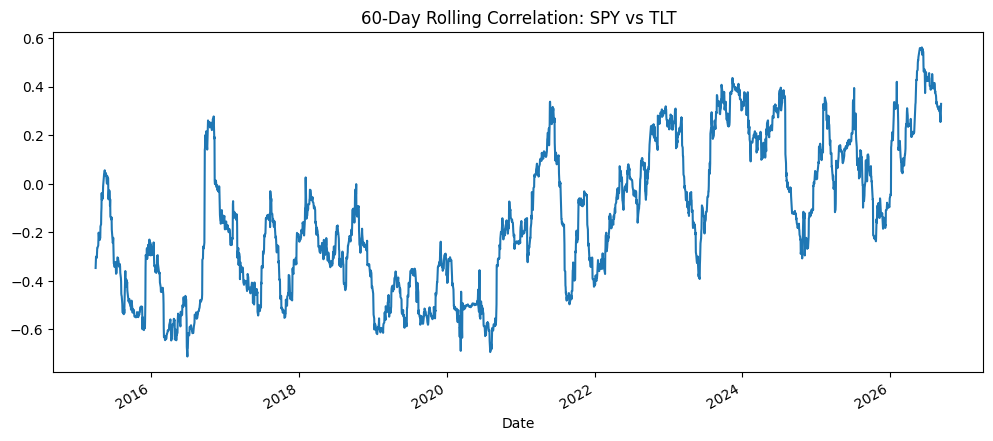

In [10]:
rolling_corr_spy_tlt.plot(
    figsize=(12, 5),
    title="60-Day Rolling Correlation: SPY vs TLT"
)